## Imports

In [ ]:
import sys
from pathlib import Path
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
import joblib

from iml2_painting_style.vae import ConvVAE, vae_loss
from iml2_painting_style.vae_engine import vae_train_one_epoch, vae_evaluate, extract_embeddings
from iml2_painting_style.dataset import PaintingStyleDataset
from iml2_painting_style.checkpoints import save_checkpoint, load_checkpoint
from iml2_painting_style.utils import set_seed, get_device

set_seed(42)
device = get_device()
print(f"Device: {device}")


Device: mps


## Configuration

In [2]:
IMAGE_SIZE = 128
LATENT_DIM = 32
BATCH_SIZE = 32
VAE_EPOCHS = 60
BETA = 0.1
LR = 1e-3
NUM_CLASSES = 8
DATA_ROOT = PROJECT_ROOT / "data"
CKPT_DIR = PROJECT_ROOT / "checkpoints"


## Data

In [3]:
vae_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = PaintingStyleDataset(DATA_ROOT / "train", transform=vae_transform)
test_dataset = PaintingStyleDataset(DATA_ROOT / "test", transform=vae_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=0)

classes = train_dataset.classes
print(f"Train: {len(train_dataset)}  Test: {len(test_dataset)}")
print(f"Classes: {classes}")


Train: 851  Test: 286
Classes: ['ArtDeco', 'Cubism', 'Impressionism', 'Japonism', 'Naturalism', 'Rococo', 'cartoon', 'photo']


## VAE Training

In [4]:
RESUME_TRAINING = True 

vae = ConvVAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=VAE_EPOCHS)

history = {"train_loss": [], "val_loss": [], "recon": [], "kl": []}
best_val = float("inf")
start_epoch = 0

if RESUME_TRAINING and (CKPT_DIR / "vae_last.pt").exists():
    vae, optimizer, scheduler, start_epoch, _, loaded_history = load_checkpoint(
        CKPT_DIR / "vae_last.pt",
        vae,
        optimizer=optimizer,
        scheduler=scheduler,
        map_location=str(device),
    )
    if loaded_history is not None:
        history = loaded_history
        best_val = min(history["val_loss"])
    print(f"Resumed from epoch {start_epoch}")

for epoch in range(start_epoch + 1, VAE_EPOCHS + 1):
    tr_loss, tr_r, tr_kl = vae_train_one_epoch(
        vae, train_loader, optimizer, device, BETA, epoch, VAE_EPOCHS)
    val_loss, val_r, val_kl = vae_evaluate(
        vae, test_loader, device, BETA, epoch, VAE_EPOCHS)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["recon"].append(tr_r)
    history["kl"].append(tr_kl)

    if val_loss < best_val:
        best_val = val_loss
        save_checkpoint(CKPT_DIR / "vae_best.pt", vae, optimizer,
                        epoch, best_val_f1=None, history=history, scheduler=scheduler)

    save_checkpoint(CKPT_DIR / "vae_last.pt", vae, optimizer,
                    epoch, best_val_f1=None, history=history, scheduler=scheduler)

    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    ep = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(ep, history["train_loss"], label="Train")
    axes[0].plot(ep, history["val_loss"], label="Val")
    axes[0].set_title(f"ELBO Loss | Epoch {epoch}/{VAE_EPOCHS}")
    axes[0].legend()
    axes[1].plot(ep, history["recon"])
    axes[1].set_title("Reconstruction Loss")
    axes[2].plot(ep, history["kl"])
    axes[2].set_title("KL Divergence")
    plt.tight_layout()
    plt.show()


Resumed from epoch 60


## Reconstruction Quality

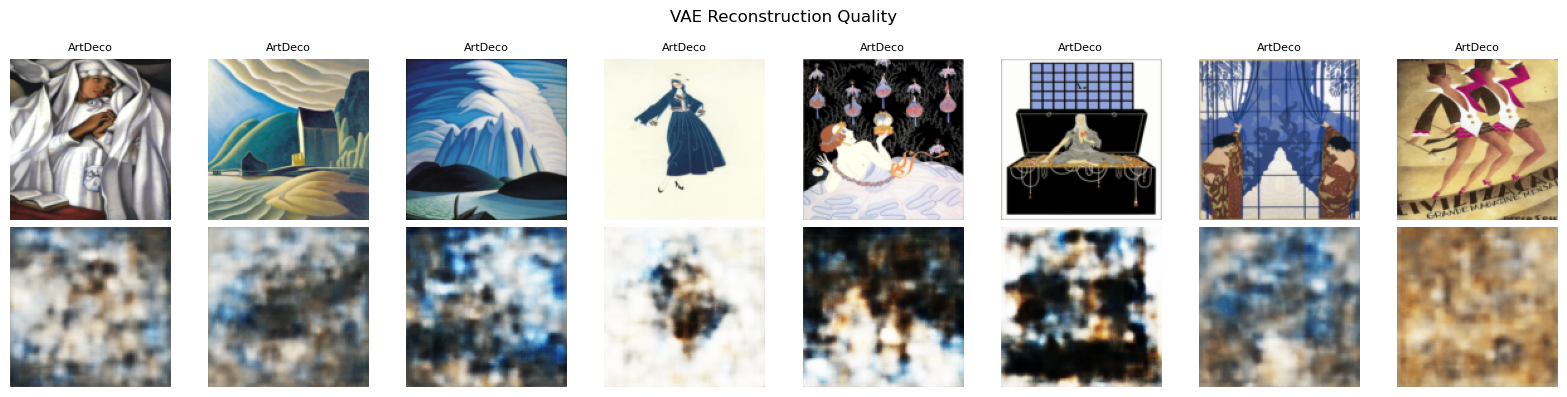

In [5]:
vae.eval()
images, labels = next(iter(test_loader))
with torch.no_grad():
    recons, _, _ = vae(images.to(device))

n_show = min(8, len(images))
fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2, 4))
for i in range(n_show):
    axes[0, i].imshow(images[i].permute(1, 2, 0).clamp(0, 1))
    axes[0, i].set_title(classes[labels[i]], fontsize=8)
    axes[0, i].axis("off")
    axes[1, i].imshow(recons[i].cpu().permute(1, 2, 0).clamp(0, 1))
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", rotation=0, labelpad=50)
axes[1, 0].set_ylabel("Reconstructed", rotation=0, labelpad=50)
plt.suptitle("VAE Reconstruction Quality")
plt.tight_layout()
plt.show()


## Extract Embeddings

In [6]:
vae, _, _, _, _, _ = load_checkpoint(
    CKPT_DIR / "vae_best.pt",
    ConvVAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE).to(device),
    optimizer=None,
    map_location=str(device),
)

train_mu, train_labels = extract_embeddings(vae, train_loader, device)
test_mu, test_labels = extract_embeddings(vae, test_loader, device)

all_mu = np.vstack([train_mu, test_mu])
all_labels = np.concatenate([train_labels, test_labels])

print(f"Train embeddings: {train_mu.shape}")
print(f"Test embeddings: {test_mu.shape}")


Train embeddings: (832, 32)
Test embeddings: (286, 32)


## Clustering

In [ ]:
kmeans = KMeans(n_clusters=NUM_CLASSES, random_state=1, n_init=5)
km_pred = kmeans.fit_predict(all_mu)

gmm = GaussianMixture(n_components=NUM_CLASSES, covariance_type="diag",
                      random_state=1, n_init=5)
gmm_pred = gmm.fit_predict(all_mu)

for name, pred in [("K-Means", km_pred), ("GMM", gmm_pred)]:
    ari = adjusted_rand_score(all_labels, pred)
    sil = silhouette_score(all_mu, pred)
    print(f"{name}: ARI={ari:.3f}  Silhouette={sil:.3f}")


K-Means: ARI=0.036  Silhouette=0.060
GMM: ARI=0.049  Silhouette=0.008


## t-SNE Visualisation

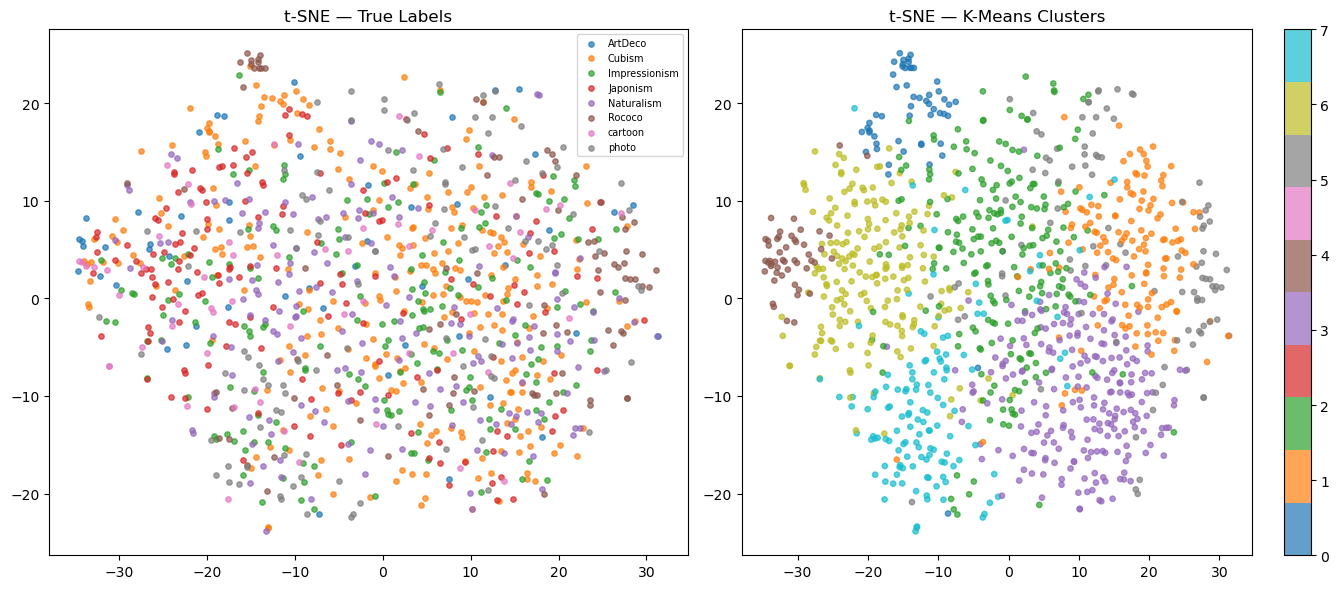

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
emb_2d = tsne.fit_transform(all_mu)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, cls in enumerate(classes):
    mask = all_labels == i
    axes[0].scatter(emb_2d[mask, 0], emb_2d[mask, 1], label=cls, s=15, alpha=0.7)
axes[0].set_title("t-SNE — True Labels")
axes[0].legend(fontsize=7)

sc = axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1], c=km_pred, cmap="tab10", s=15, alpha=0.7)
axes[1].set_title("t-SNE — K-Means Clusters")
plt.colorbar(sc, ax=axes[1])
plt.tight_layout()
plt.show()


## Cluster Centroids

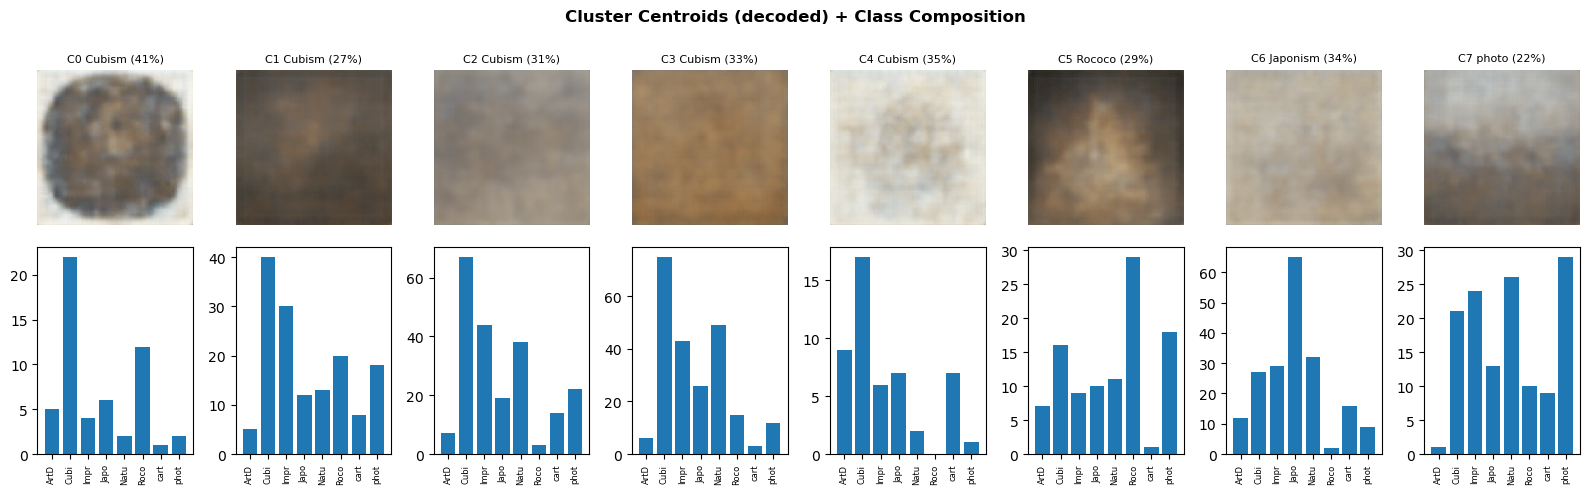

In [9]:
centroids = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32).to(device)
with torch.no_grad():
    decoded = vae.decode(centroids).cpu()

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 2, 5))
for k in range(NUM_CLASSES):
    mask = km_pred == k
    dominant = np.bincount(all_labels[mask]).argmax()
    purity = np.bincount(all_labels[mask]).max() / mask.sum()

    axes[0, k].imshow(decoded[k].permute(1, 2, 0).clamp(0, 1))
    axes[0, k].set_title(f"C{k} {classes[dominant]} ({purity:.0%})", fontsize=8)
    axes[0, k].axis("off")

    counts = np.bincount(all_labels[mask], minlength=NUM_CLASSES)
    axes[1, k].bar(range(NUM_CLASSES), counts)
    axes[1, k].set_xticks(range(NUM_CLASSES))
    axes[1, k].set_xticklabels([c[:4] for c in classes], rotation=90, fontsize=6)

plt.suptitle("Cluster Centroids (decoded) + Class Composition", fontweight="bold")
plt.tight_layout()
plt.show()


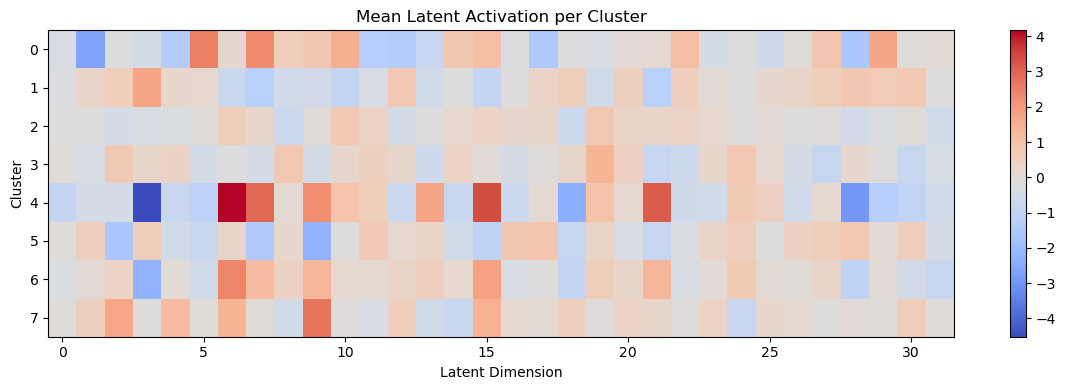

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
cluster_means = np.array([
    all_mu[km_pred == k].mean(axis=0) for k in range(NUM_CLASSES)
])
im = ax.imshow(cluster_means, aspect='auto', cmap='coolwarm')
ax.set_xlabel('Latent Dimension')
ax.set_ylabel('Cluster')
ax.set_title('Mean Latent Activation per Cluster')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
scaler = StandardScaler()
train_mu_scaled = scaler.fit_transform(train_mu)
test_mu_scaled = scaler.transform(test_mu)

## Gradient Boosting Classification

In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='mlogloss',
    nthread =1,
    random_state=1,
)
xgb.fit(train_mu_scaled, train_labels)
xgb_pred = xgb.predict(test_mu_scaled)

xgb_acc = accuracy_score(test_labels, xgb_pred)
xgb_f1 = f1_score(test_labels, xgb_pred, average="macro")
print(f"XGBoost — Accuracy: {xgb_acc:.3f}  Macro F1: {xgb_f1:.3f}")

joblib.dump({'model': xgb, 'scaler': scaler}, CKPT_DIR / 'xgboost.pkl')
print(f"Saved: {CKPT_DIR / 'xgboost.pkl'}")


XGBoost — Accuracy: 0.350  Macro F1: 0.308
Saved: /Users/arpinejanunts/Desktop/iml2-painting-style/checkpoints/xgboost.pkl
